## Imports and directory setup
In this section, we import the required Python libraries and define folder paths used throughout the EDA notebook.

../data/processed contains the processed datasets produced by the data ingestion notebook.
../plots stores all EDA figures generated in this notebook (required for reproducibility and validation).

In [74]:
# Imports + Folders
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PROCESSED = Path("../data/processed")
PLOTS_DIR = Path("../plots")
PLOTS_DIR.mkdir(parents=True,exist_ok=True)


## Load processed datasets
In this section, we load the processed training and test datasets generated by the data ingestion notebook.The EDA notebook operates only on these processed files to ensure reproducibility and a clear pipeline separation between ingestion and analysis.

In [75]:
#Loaded processed data from ingestion

with open(DATA_PROCESSED / "train.pkl", "rb") as f:
    train_df = pickle.load(f)

with open(DATA_PROCESSED / "test.pkl", "rb") as f:
    test_df = pickle.load(f)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()

Train: (574945, 341)
Test: (107, 336)


,row_id,sequence_type,sequence_id,sequence_counter,subject,orientation,behavior,phase,gesture,acc_x,...,tof_5_v54,tof_5_v55,tof_5_v56,tof_5_v57,tof_5_v58,tof_5_v59,tof_5_v60,tof_5_v61,tof_5_v62,tof_5_v63
0,SEQ_000007_000000,Target,SEQ_000007,0,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.683594,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,SEQ_000007_000001,Target,SEQ_000007,1,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.949219,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,SEQ_000007_000002,Target,SEQ_000007,2,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.722656,...,-1.0,-1.0,112.0,119.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,SEQ_000007_000003,Target,SEQ_000007,3,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,6.601562,...,-1.0,-1.0,101.0,111.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
4,SEQ_000007_000004,Target,SEQ_000007,4,SUBJ_059520,Seated Lean Non Dom - FACE DOWN,Relaxes and moves hand to target location,Transition,Cheek - pinch skin,5.566406,...,-1.0,-1.0,101.0,109.0,125.0,-1.0,-1.0,-1.0,-1.0,-1.0


# Dataset structure overview
Before plotting, we inspect key identifies and labels in the training dataset to understand how the data is organized. We examined the number of unique sequences, unique objects and gesture classes.

In [76]:
print(f"Unique sequences (train): {train_df["sequence_id"].nunique()}")
print(f"Unique subjects (train): {train_df["subject"].nunique()}")
print(f"Unique gestures (train): {train_df["gesture"].nunique()}")

train_df[["sequence_id", "sequence_counter", "gesture", "behavior", "phase", "subject"]].head(10)

Unique sequences (train): 8151
Unique subjects (train): 81
Unique gestures (train): 18


,sequence_id,sequence_counter,gesture,behavior,phase,subject
0,SEQ_000007,0,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
1,SEQ_000007,1,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
2,SEQ_000007,2,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
3,SEQ_000007,3,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
4,SEQ_000007,4,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
5,SEQ_000007,5,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
6,SEQ_000007,6,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
7,SEQ_000007,7,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
8,SEQ_000007,8,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520
9,SEQ_000007,9,Cheek - pinch skin,Relaxes and moves hand to target location,Transition,SUBJ_059520


## Gesture label distribution
We visualize the distribution of gesture labels in the training dataset to identify potential class imbalance.

Understanding class imbalance is important because it can affect model performance and evaluation. In particular, class imbalance motivates the use of macro-averaged F1-score during evaluation rather than accuracy alone.

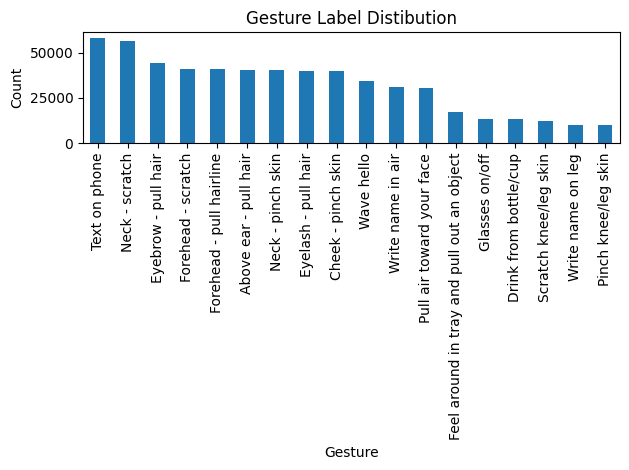

In [77]:
#Gesture Distribution Plot 
gesture_counts = train_df["gesture"].value_counts()

plt.figure()
gesture_counts.plot(kind='bar')
plt.title("Gesture Label Distibution")
plt.xlabel("Gesture")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "gesture_distribution.png", dpi=200)
plt.show()

## Sequence length distribution
We analyze the distribution of sequence lengths in the training dataset by counting the number of time steps associated with each sequence_id.
This plot helps determine whether sequences are fixed-length or variable-length. If sequence lengths vary, padding or truncation is required during preprocessing before training sequence-based models.

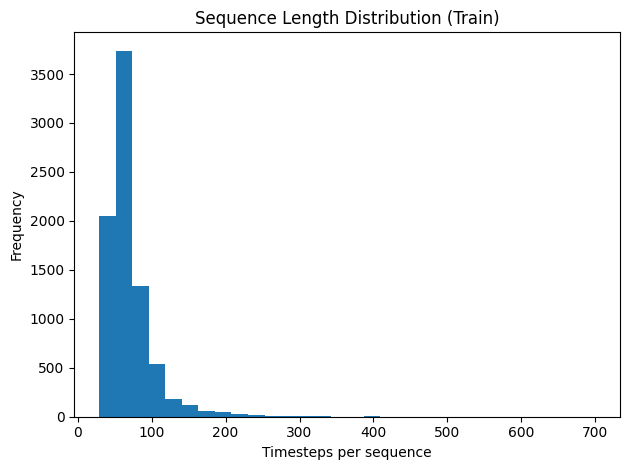

In [78]:
#Sequence length distribution
seq_lengths = train_df.groupby("sequence_id").size()

plt.figure()
plt.hist(seq_lengths, bins=30)
plt.title("Sequence Length Distribution (Train)")
plt.xlabel("Timesteps per sequence")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "sequence_length_distribution.png", dpi=200)
plt.show()

## Check label distribution by subject

In this cell, I analyze the data by subject to see how the gesture labels are distributed across different people. This is important because subjects can have very different amounts of data, and it can also affect evaluation if we randomly split data without considering subjects.

I create a cross tab table between subject and the label column (gesture). Then I print how many subjects and how many classes exist. After that, I sum each subject’s total samples and plot a bar chart to visualize how many samples come from each subject.

Output: number of subjects and classes, top subjects by sample count, and a bar chart showing samples per subject.

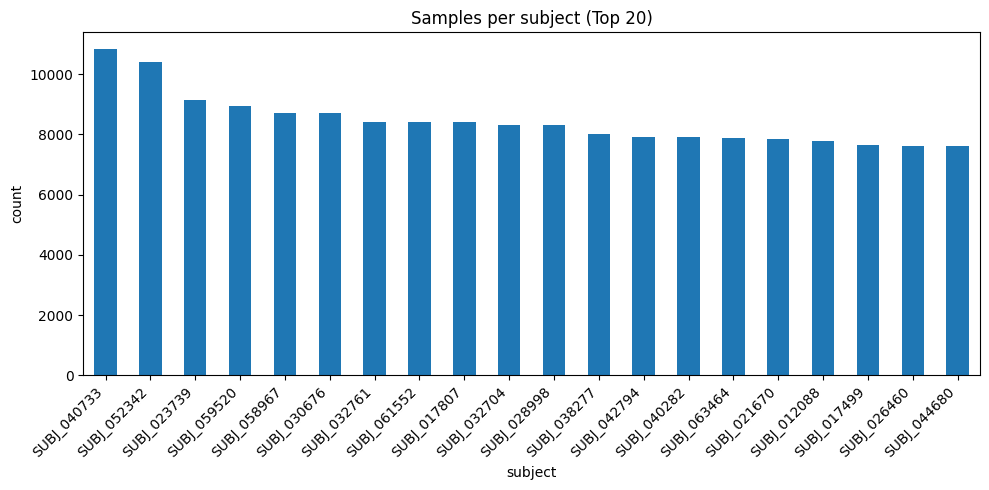

Total subjects: 81
Top subjects:
 subject
SUBJ_040733    10848
SUBJ_052342    10393
SUBJ_023739     9154
SUBJ_059520     8947
SUBJ_058967     8718
SUBJ_030676     8700
SUBJ_032761     8420
SUBJ_061552     8412
SUBJ_017807     8409
SUBJ_032704     8322
SUBJ_028998     8307
SUBJ_038277     8004
SUBJ_042794     7928
SUBJ_040282     7901
SUBJ_063464     7891
SUBJ_021670     7865
SUBJ_012088     7781
SUBJ_017499     7644
SUBJ_026460     7629
SUBJ_044680     7618
Name: count, dtype: int64


In [79]:
# Samples per subject (Top N)
N = 20

counts = train_df["subject"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
counts.head(N).plot(kind="bar")
plt.title(f"Samples per subject (Top {N})")
plt.xlabel("subject")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Total subjects:", counts.shape[0])
print("Top subjects:\n", counts.head(N))


## Example accelerometer time-series
We visualize the accelerometer signals (acc_x, acc_y, acc_z) for a single example sequence to understand the temporal structure and scale of the sensor data.
This plot confirms that the data consists of multivariate time-series signals, supporting the use of sequence-based models such as CNNs or recurrent neural networks (LSTM/BiLSTM).

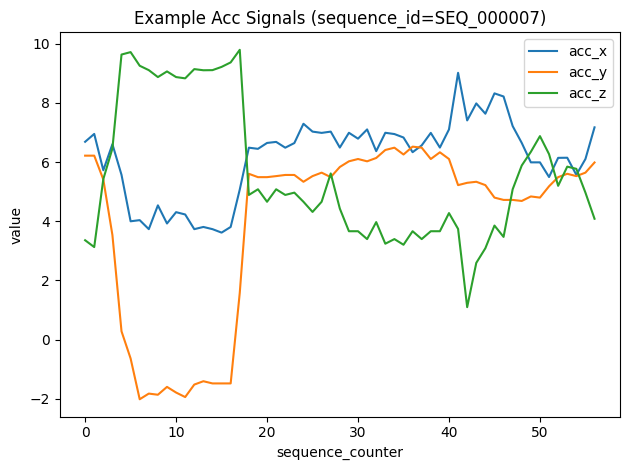

In [80]:
example_seq_id = train_df["sequence_id"].iloc[0]
seq_df = train_df[train_df["sequence_id"] == example_seq_id].sort_values("sequence_counter")

plt.figure()
plt.plot(seq_df["sequence_counter"], seq_df["acc_x"], label="acc_x")
plt.plot(seq_df["sequence_counter"], seq_df["acc_y"], label="acc_y")
plt.plot(seq_df["sequence_counter"], seq_df["acc_z"], label="acc_z")
plt.title(f"Example Acc Signals (sequence_id={example_seq_id})")
plt.xlabel("sequence_counter")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "example_acc_signal.png", dpi=200)
plt.show()

## TOF Sensor Missing Value Analysis
Time-of-Flight (TOF) sensors are directly used in the models described in the reference paper. In the dataset, TOF measurements use a value of -1.0 to indicate missing or invalid readings.

In this analysis, we:

Identify all TOF-related columns,
Aggregate all TOF measurements across the training dataset, and
Compare the number of valid measurements to invalid (-1.0) values.
This visualization helps motivate preprocessing decisions related to TOF data handling (e.g., masking, imputation, or exclusion of unreliable channels).

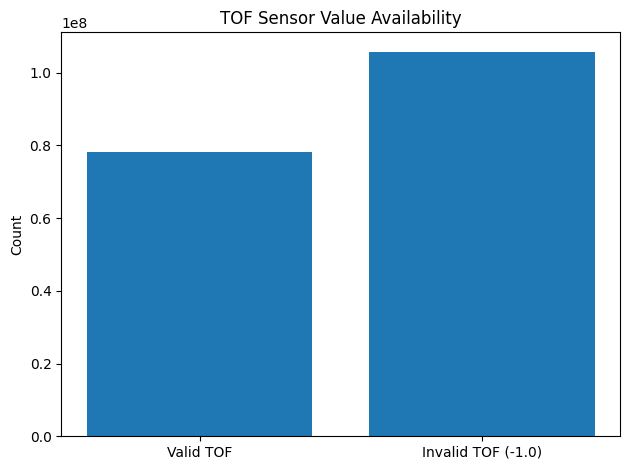

In [81]:
# Identify TOF sensor columns
tof_cols = [c for c in train_df.columns if c.lower().startswith("tof_")]

# Flatten all TOF values across sequences and time
tof_values = train_df[tof_cols].values.flatten()

# Count valid vs invalid (-1.0) measurements
missing = np.sum(tof_values == -1.0)
valid = np.sum(tof_values != -1.0)

# Plot availability of TOF data
plt.figure()
plt.bar(["Valid TOF", "Invalid TOF (-1.0)"], [valid, missing])
plt.title("TOF Sensor Value Availability")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "tof_invalid_rate.png", dpi=200)
plt.show()

## Verification of generated plots
To ensure reproducibility and validation, we list all figures generated by this notebook. All plots are saved to the plots/ directory and can be regenerated by running this notebook from a fresh clone of the repository.

In [82]:
print("Plots generated:")
for p in sorted(PLOTS_DIR.glob("*.png")):
    print(" -", p.name)

Plots generated:
 - example_acc_signal.png
 - gesture_distribution.png
 - sequence_length_distribution.png
 - tof_invalid_rate.png
